# Part 1.B  Fine-tuning GPT2 with LoRA

In Part 1.A I trained a transformer from scratch. This time I start from the pretrained
GPT2 (`openai-community/gpt2`, 124M params) and only train a small number of extra
weights on top of it.

Fine-tuning all 124M parameters would be slow and needs a lot of memory. LoRA gets around
this: the pretrained weights stay frozen and we add two small matrices next to each one
we want to adapt. For a frozen weight matrix $W$ the output becomes

$$h = Wx + \frac{\alpha}{r}BAx$$

where $A$ is $r \times d$ and $B$ is $d \times r$, with $r$ much smaller than $d$. $A$ gets
random values and $B$ starts at zero, so $BA = 0$ at the beginning and the model is still
just GPT2. Training then only has to learn the difference.

I wrote LoRA by hand here  no PEFT or other adapter libraries. The adapters go on the
query, key and value projections.

Requirements for this part: PPL below 250, and better than what Part 1.A got.

In [1]:
import math
import os
import urllib.request

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, GPT2LMHeadModel

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [2]:
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

SEED         = 42
BLOCK_SIZE   = 64      # how many tokens per block
BATCH_SIZE   = 64
N_EPOCHS     = 5
PATIENCE     = 3
WEIGHT_DECAY = 0.01
CLIP         = 1.0
LORA_DROPOUT = 0.05
AMP          = torch.cuda.is_available()   # fp16 on the T4 tensor cores

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Device     : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU        : {torch.cuda.get_device_name(0)}')
print(f'Block size : {BLOCK_SIZE} tokens | batch {BATCH_SIZE} | epochs {N_EPOCHS}')
print(f'Mixed precision: {AMP}')

Device     : cuda:0
GPU        : Tesla T4
Block size : 64 tokens | batch 64 | epochs 5
Mixed precision: True


## 1. Data

Same Penn Treebank data and same GPT2 tokenizer as Part 1.A, so the two parts can be
compared directly.

The batching is different though. In Part 1.A I padded sentences to the longest one in
each batch. Here I glue the whole tokenized corpus together and cut it into fixed 64-token
blocks instead. No padding at all this way, which is faster and makes the perplexity
easier to compute since every token counts.

In [3]:
os.makedirs('dataset/PennTreeBank', exist_ok=True)
base = 'https://raw.githubusercontent.com/massimo-rizzoli/NLU-2026-Labs/main/labs/dataset/PennTreeBank'
for split in ['ptb.train.txt', 'ptb.valid.txt', 'ptb.test.txt']:
    dst = f'dataset/PennTreeBank/{split}'
    if not os.path.exists(dst):
        urllib.request.urlretrieve(f'{base}/{split}', dst)
        print(f'Downloaded {split}')
    else:
        print(f'Already present: {split}')


def read_file(path, eos_token='<eos>'):
    with open(path, 'r') as f:
        return [line.strip() + ' ' + eos_token for line in f.readlines()]


train_raw = read_file('dataset/PennTreeBank/ptb.train.txt')
dev_raw   = read_file('dataset/PennTreeBank/ptb.valid.txt')
test_raw  = read_file('dataset/PennTreeBank/ptb.test.txt')

tokenizer = AutoTokenizer.from_pretrained('openai-community/gpt2')
tokenizer.pad_token = tokenizer.eos_token

print(f'\nSentences -- train: {len(train_raw)} | dev: {len(dev_raw)} | test: {len(test_raw)}')
print(f'Vocabulary: {len(tokenizer)} | EOS/PAD id: {tokenizer.pad_token_id}')

Already present: ptb.train.txt
Already present: ptb.valid.txt
Already present: ptb.test.txt


/home/disi/miniconda3/envs/nlu/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



Sentences -- train: 42068 | dev: 3370 | test: 3761
Vocabulary: 50257 | EOS/PAD id: 50256


In [4]:
def pack_blocks(raw, tokenizer, block_size=BLOCK_SIZE):
    # glue everything together, then cut it into equal chunks
    ids = []
    for line in raw:
        ids.extend(tokenizer(line).input_ids)
    n_blocks = len(ids) // block_size
    return torch.tensor(ids[:n_blocks * block_size], dtype=torch.long).view(n_blocks, block_size)


train_blocks = pack_blocks(train_raw, tokenizer)
dev_blocks   = pack_blocks(dev_raw, tokenizer)
test_blocks  = pack_blocks(test_raw, tokenizer)

train_loader = DataLoader(train_blocks, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_blocks,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_blocks,  batch_size=BATCH_SIZE)

table1 = pd.DataFrame([
    {'Split': 'Train',       'Sentences': len(train_raw), 'Packed blocks': len(train_blocks),
     'Main purpose': 'Adapter learning'},
    {'Split': 'Development', 'Sentences': len(dev_raw),   'Packed blocks': len(dev_blocks),
     'Main purpose': 'Model selection'},
    {'Split': 'Test',        'Sentences': len(test_raw),  'Packed blocks': len(test_blocks),
     'Main purpose': 'Final held-out evaluation'},
])
display(table1)
print(f'Batches -- train: {len(train_loader)} | dev: {len(dev_loader)} | test: {len(test_loader)}')

,Split,Sentences,Packed blocks,Main purpose
0,Train,42068,19729,Adapter learning
1,Development,3370,1561,Model selection
2,Test,3761,1768,Final held-out evaluation


Batches -- train: 309 | dev: 25 | test: 28


## 2. LoRA implementation

One annoying detail about GPT2: it doesn't have separate weight matrices for query, key
and value. They're fused into a single `Conv1D` called `c_attn` that outputs all three
stacked together, and the attention code splits them afterwards.

So to put a separate adapter on each one, I wrap that layer. The original `Conv1D` is kept
and frozen, three small adapters compute their own deltas, and I concatenate those back in
the same `[q | k | v]` order the rest of the model expects.

Each layer adds `3 * (r*768 + 768*r) = 4608*r` trainable weights, so over GPT2's 12 blocks
that's `55296*r` — about 0.88M at rank 16 and 1.77M at rank 32.

In [5]:
class LoRAQKV(nn.Module):
    # GPT2 keeps q, k and v in one fused Conv1D, so I wrap it and add a separate
    # adapter for each of the three. The original layer stays frozen.

    def __init__(self, base, rank, alpha, dropout=LORA_DROPOUT):
        super().__init__()
        self.base = base                        # the original layer, frozen
        d_in, d_out = base.weight.shape         # (n_embd, 3 * n_embd)
        self.d       = d_out // 3
        self.rank    = rank
        self.alpha   = alpha
        self.scaling = alpha / rank
        self.drop    = nn.Dropout(dropout)

        # 0 is query, 1 is key, 2 is value
        self.lora_A = nn.Parameter(torch.zeros(3, rank, d_in))
        self.lora_B = nn.Parameter(torch.zeros(3, self.d, rank))
        nn.init.normal_(self.lora_A, mean=0.0, std=0.02)   # random init for A
        # B is left at zero so the adapter starts off doing nothing

    def forward(self, x):
        out = self.base(x)                      # original output
        xd  = self.drop(x)
        delta = torch.cat(
            [(xd @ self.lora_A[i].T) @ self.lora_B[i].T for i in range(3)], dim=-1)
        return out + self.scaling * delta


class GPT2_LoRA(GPT2LMHeadModel):
    # GPT2 with my own LoRA adapters on q, k and v

    @classmethod
    def from_pretrained(cls, *args, rank=8, alpha=16, lora_dropout=LORA_DROPOUT, **kwargs):
        model = super().from_pretrained(*args, **kwargs)
        model.inject_lora(rank, alpha, lora_dropout)
        return model

    def inject_lora(self, rank, alpha, lora_dropout=LORA_DROPOUT):
        for p in self.parameters():                     # freeze everything first
            p.requires_grad = False
        for block in self.transformer.h:                # then swap in the adapters
            block.attn.c_attn = LoRAQKV(block.attn.c_attn, rank, alpha, lora_dropout)
        for name, p in self.named_parameters():         # and only let those train
            if 'lora_' in name:
                p.requires_grad = True
        self.lora_rank, self.lora_alpha = rank, alpha
        return self


def param_stats(model, verbose=True):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if verbose:
        print(f'  total params     : {total:,}')
        print(f'  trainable params : {trainable:,} ({100 * trainable / total:.3f}%)')
        print(f'  frozen params    : {total - trainable:,}')
    return total, trainable


print('LoRA implementation defined.')

LoRA implementation defined.


## 3. Training and evaluation

Only the adapters get gradients, everything else is frozen. GPT2 shifts the labels
internally so I can just pass the same tensor as both input and labels.

I accumulate the loss weighted by token count rather than averaging the per-batch
averages, so the perplexity is the real per-token value. Each block of length `L` gives
`L - 1` predictions since the first token has nothing before it. No padding to worry about
here.

In [6]:
def train_loop(loader, optimizer, model, scaler=None, clip=CLIP):
    model.train()
    loss_sum, n_total = 0.0, 0
    trainable = [p for p in model.parameters() if p.requires_grad]
    for batch in tqdm(loader, desc='Training', leave=False):
        batch = batch.to(DEVICE)
        optimizer.zero_grad()

        if scaler is not None:
            # fp16 forward/backward, fp32 master weights - the T4 has tensor cores
            with torch.autocast('cuda', dtype=torch.float16):
                out = model(input_ids=batch, labels=batch)
            scaler.scale(out.loss).backward()
            scaler.unscale_(optimizer)              # unscale before clipping
            torch.nn.utils.clip_grad_norm_(trainable, clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            out = model(input_ids=batch, labels=batch)
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable, clip)
            optimizer.step()

        n = batch.shape[0] * (batch.shape[1] - 1)
        loss_sum += out.loss.item() * n
        n_total  += n
    avg = loss_sum / n_total
    return math.exp(avg), avg


def eval_loop(loader, model):
    model.eval()
    loss_sum, n_total = 0.0, 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            batch = batch.to(DEVICE)
            with torch.autocast('cuda', enabled=AMP, dtype=torch.float16):
                out = model(input_ids=batch, labels=batch)
            n = batch.shape[0] * (batch.shape[1] - 1)
            loss_sum += out.loss.item() * n
            n_total  += n
    avg = loss_sum / n_total
    return math.exp(avg), avg

### Quick check that the adapter does nothing yet

Since `lora_B` is all zeros to start with, wrapping the model shouldn't change its
predictions at all. If I score plain GPT2 and the wrapped version on the dev set they
should come out the same. If they don't, the adapter is plugged into the wrong place.

In [7]:
import gc

plain = GPT2LMHeadModel.from_pretrained('openai-community/gpt2').to(DEVICE)
ppl_plain, _ = eval_loop(dev_loader, plain)
n_backbone = sum(p.numel() for p in plain.parameters())
del plain; gc.collect(); torch.cuda.empty_cache()

wrapped = GPT2_LoRA.from_pretrained('openai-community/gpt2', rank=32, alpha=64).to(DEVICE)
ppl_wrapped, _ = eval_loop(dev_loader, wrapped)

print(f'\npretrained GPT2       dev PPL : {ppl_plain:.4f}')
print(f'LoRA-wrapped (B = 0)  dev PPL : {ppl_wrapped:.4f}')
print(f'difference                    : {abs(ppl_plain - ppl_wrapped):.6f}')
assert abs(ppl_plain - ppl_wrapped) < 1e-3, 'LoRA is not a no-op at initialisation!'
print('\nVerified: zero-initialised B makes the adapter an exact no-op.')

print('\n--- trainable parameters at rank 32 ---')
param_stats(wrapped)
n_layers = len(wrapped.transformer.h)
print(f'  formula          : 3 proj x 2 matrices x 768 x rank 32 x {n_layers} layers '
      f'= {3 * 2 * 768 * 32 * n_layers:,}')
del wrapped; gc.collect(); torch.cuda.empty_cache()

print(f'\nNote: pretrained GPT2 already scores {ppl_plain:.2f} on PTB with no training at all,')
print(f'well below the Part 1.A result of {36.44:.2f} - this is the value of pretraining.')

/home/disi/miniconda3/envs/nlu/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]


pretrained GPT2       dev PPL : 137.0948
LoRA-wrapped (B = 0)  dev PPL : 137.0948
difference                    : 0.000000

Verified: zero-initialised B makes the adapter an exact no-op.

--- trainable parameters at rank 32 ---
  total params     : 126,209,280
  trainable params : 1,769,472 (1.402%)
  frozen params    : 124,439,808
  formula          : 3 proj x 2 matrices x 768 x rank 32 x 12 layers = 1,769,472

Note: pretrained GPT2 already scores 137.09 on PTB with no training at all,
well below the Part 1.A result of 36.44 - this is the value of pretraining.


## 4. Experiments

Three settings, changing the rank/alpha pair and the learning rate. I pick the best one on
the dev set and only touch the test set once, at the end, with whichever checkpoint won.

In [8]:
results = []


def run_experiment(name, rank, alpha, lr, lora_dropout=LORA_DROPOUT,
                   n_epochs=N_EPOCHS, patience=PATIENCE):
    print(f'\n{"=" * 68}')
    print(f'Experiment : {name}')
    print(f'  rank={rank}  alpha={alpha}  lr={lr}  lora_dropout={lora_dropout}')
    print('=' * 68)

    torch.manual_seed(SEED)
    model = GPT2_LoRA.from_pretrained('openai-community/gpt2', rank=rank, alpha=alpha,
                                      lora_dropout=lora_dropout).to(DEVICE)
    total, trainable = param_stats(model)

    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad],
                            lr=lr, weight_decay=WEIGHT_DECAY)

    scaler = torch.amp.GradScaler('cuda') if AMP else None

    train_hist, dev_hist = [], []
    best_ppl, best_state, best_epoch, pat = math.inf, None, -1, patience

    pbar = tqdm(range(1, n_epochs + 1), desc='Epochs')
    for epoch in pbar:
        train_ppl, _ = train_loop(train_loader, optimizer, model, scaler)
        dev_ppl,   _ = eval_loop(dev_loader, model)
        train_hist.append(train_ppl)
        dev_hist.append(dev_ppl)
        pbar.set_description(f'epoch {epoch}: train {train_ppl:.2f} / dev {dev_ppl:.2f}')
        print(f'  epoch {epoch}: train PPL {train_ppl:7.2f} | dev PPL {dev_ppl:7.2f}')

        if dev_ppl < best_ppl:
            best_ppl, best_epoch = dev_ppl, epoch
            # no point saving the frozen backbone, just keep the adapters
            best_state = {k: v.detach().clone()
                          for k, v in model.state_dict().items() if 'lora_' in k}
            pat = patience
        else:
            pat -= 1
            if pat <= 0:
                print(f'  early stop at epoch {epoch}')
                break

    model.load_state_dict(best_state, strict=False)
    test_ppl, _ = eval_loop(test_loader, model)
    print(f'  -> best epoch {best_epoch} | dev PPL {best_ppl:.2f} | test PPL {test_ppl:.2f}')

    results.append({
        'name': name, 'rank': rank, 'alpha': alpha, 'lr': lr,
        'lora_dropout': lora_dropout, 'trainable': trainable,
        'best_epoch': best_epoch,
        'dev_ppl': round(best_ppl, 2), 'test_ppl': round(test_ppl, 2),
        'train_hist': [round(v, 2) for v in train_hist],
        'dev_hist': [round(v, 2) for v in dev_hist],
    })
    del model, optimizer
    gc.collect(); torch.cuda.empty_cache()
    return best_ppl, test_ppl

In [9]:
run_experiment('lora_r16_a32_lr5e4', rank=16, alpha=32, lr=5e-4)


Experiment : lora_r16_a32_lr5e4
  rank=16  alpha=32  lr=0.0005  lora_dropout=0.05
  total params     : 125,324,544
  trainable params : 884,736 (0.706%)
  frozen params    : 124,439,808


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/309 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 1: train PPL   38.66 | dev PPL   27.96


...

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 5: train PPL   25.43 | dev PPL   23.72


Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]

  -> best epoch 5 | dev PPL 23.72 | test PPL 21.58


(23.720806254902545, 21.5763269932197)

In [10]:
run_experiment('lora_r32_a64_lr5e4', rank=32, alpha=64, lr=5e-4)


Experiment : lora_r32_a64_lr5e4
  rank=32  alpha=64  lr=0.0005  lora_dropout=0.05
  total params     : 126,209,280
  trainable params : 1,769,472 (1.402%)
  frozen params    : 124,439,808


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/309 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 1: train PPL   36.07 | dev PPL   26.79


...

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 5: train PPL   24.12 | dev PPL   22.94


Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]

  -> best epoch 5 | dev PPL 22.94 | test PPL 20.87


(22.94233791525527, 20.871783346254613)

In [11]:
run_experiment('lora_r32_a64_lr3e4', rank=32, alpha=64, lr=3e-4)


Experiment : lora_r32_a64_lr3e4
  rank=32  alpha=64  lr=0.0003  lora_dropout=0.05
  total params     : 126,209,280
  trainable params : 1,769,472 (1.402%)
  frozen params    : 124,439,808


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/309 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 1: train PPL   39.31 | dev PPL   28.09


...

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 5: train PPL   25.52 | dev PPL   23.82


Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]

  -> best epoch 5 | dev PPL 23.82 | test PPL 21.64


(23.819643364655924, 21.64191478616475)

### Results

In [12]:
table2 = pd.DataFrame(results)[
    ['name', 'rank', 'alpha', 'lr', 'lora_dropout', 'best_epoch', 'dev_ppl',
     'test_ppl', 'trainable']
].rename(columns={
    'name': 'Experiment', 'rank': 'Rank', 'alpha': 'alpha', 'lr': 'LR',
    'lora_dropout': 'LoRA dropout', 'best_epoch': 'Best epoch',
    'dev_ppl': 'Dev PPL', 'test_ppl': 'Test PPL', 'trainable': 'Trainable params'})
table2['Trainable params'] = (table2['Trainable params'] / 1e6).round(2).astype(str) + 'M'
display(table2)

best = min(results, key=lambda r: r['dev_ppl'])
print(f"Selected: {best['name']}  dev PPL {best['dev_ppl']} | test PPL {best['test_ppl']} "
      f"| {best['trainable'] / 1e6:.2f}M trainable")

,Experiment,Rank,alpha,LR,LoRA dropout,Best epoch,Dev PPL,Test PPL,Trainable params
0,lora_r16_a32_lr5e4,16,32,0.0005,0.05,5,23.72,21.58,0.88M
1,lora_r32_a64_lr5e4,32,64,0.0005,0.05,5,22.94,20.87,1.77M
2,lora_r32_a64_lr3e4,32,64,0.0003,0.05,5,23.82,21.64,1.77M


Selected: lora_r32_a64_lr5e4  dev PPL 22.94 | test PPL 20.87 | 1.77M trainable


### Plots

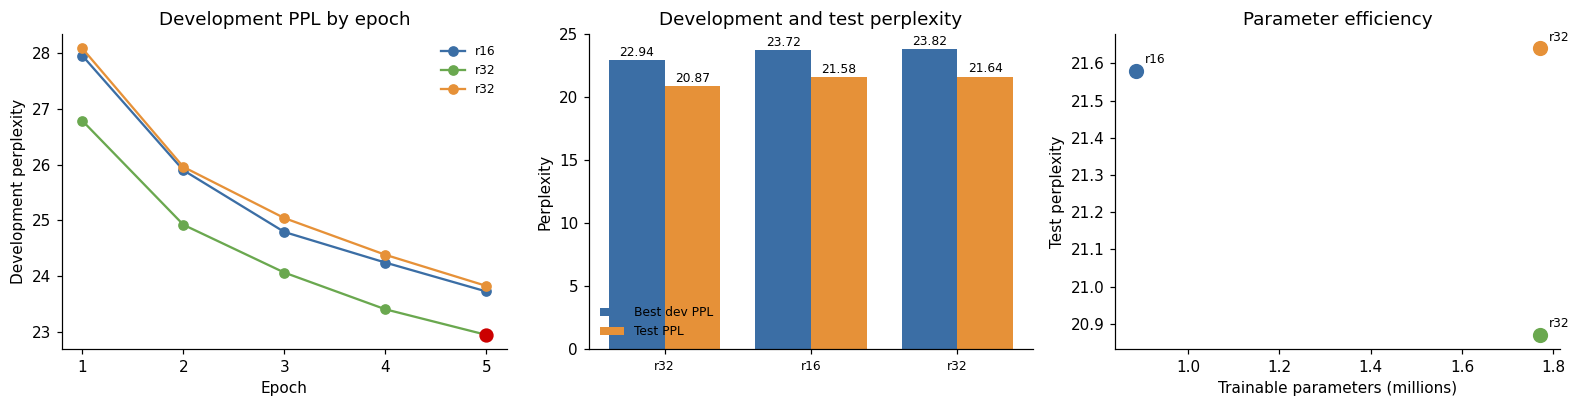

In [13]:
colors = ['#3b6ea5', '#6aa84f', '#e69138']
fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.8))

# (a) development perplexity by epoch
for r, c in zip(results, colors):
    ep = np.arange(1, len(r['dev_hist']) + 1)
    axes[0].plot(ep, r['dev_hist'], marker='o', color=c,
                 label=r['name'].split('_')[1])
axes[0].scatter([best['best_epoch']], [best['dev_ppl']], color='#cc0000', zorder=5, s=70)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Development perplexity')
axes[0].set_title('Development PPL by epoch')
axes[0].set_xticks(np.arange(1, max(len(r['dev_hist']) for r in results) + 1))
axes[0].legend(frameon=False, fontsize=8)

# (b) dev / test per configuration
order = sorted(results, key=lambda r: r['dev_ppl'])
x = np.arange(len(order)); w = 0.38
b1 = axes[1].bar(x - w / 2, [r['dev_ppl'] for r in order], w, label='Best dev PPL',
                 color='#3b6ea5')
b2 = axes[1].bar(x + w / 2, [r['test_ppl'] for r in order], w, label='Test PPL',
                 color='#e69138')
for bars in (b1, b2):
    axes[1].bar_label(bars, fmt='%.2f', fontsize=8, padding=1)
axes[1].set_xticks(x, [r['name'].split('_')[1] for r in order], fontsize=8)
axes[1].set_ylabel('Perplexity'); axes[1].set_title('Development and test perplexity')
axes[1].legend(frameon=False, fontsize=8)

# (c) trainable parameters vs test perplexity
for r, c in zip(results, colors):
    axes[2].scatter(r['trainable'] / 1e6, r['test_ppl'], s=80, color=c)
    axes[2].annotate(r['name'].split('_')[1], (r['trainable'] / 1e6, r['test_ppl']),
                     textcoords='offset points', xytext=(6, 5), fontsize=8)
axes[2].set_xlabel('Trainable parameters (millions)')
axes[2].set_ylabel('Test perplexity')
axes[2].set_title('Parameter efficiency')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Comparing against Part 1.A

The Part 1.A row is the best model from `part1A.ipynb`.

,Part,Model family,Selected configuration,Training method,Dev PPL,Test PPL,Trainable params
0,Part 1.A,Scratch GPT-style Transformer,step5_dropout01,From scratch,40.49,36.44,20.66M
1,Part 1.B,GPT2 with LoRA,lora_r32_a64_lr5e4,Parameter-efficient fine-tuning,22.94,20.87,1.77M


Relative reduction -- dev: 43.34%  |  test: 42.73%


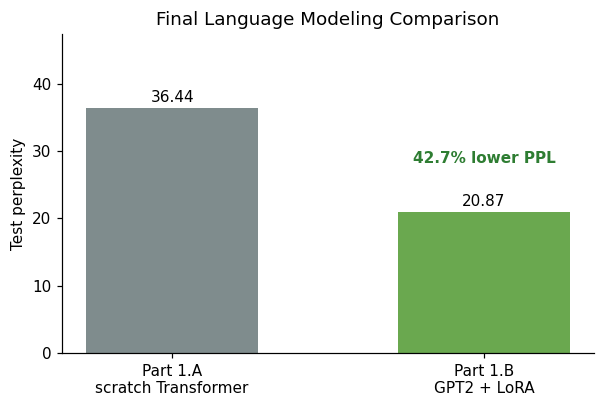

In [14]:
PART_1A = {'name': 'step5_dropout01', 'dev_ppl': 40.49, 'test_ppl': 36.44, 'params': 20658240}   # best result from part1A.ipynb

table3 = pd.DataFrame([
    {'Part': 'Part 1.A', 'Model family': 'Scratch GPT-style Transformer',
     'Selected configuration': PART_1A['name'], 'Training method': 'From scratch',
     'Dev PPL': PART_1A['dev_ppl'], 'Test PPL': PART_1A['test_ppl'],
     'Trainable params': f"{PART_1A['params'] / 1e6:.2f}M"},
    {'Part': 'Part 1.B', 'Model family': 'GPT2 with LoRA',
     'Selected configuration': best['name'],
     'Training method': 'Parameter-efficient fine-tuning',
     'Dev PPL': best['dev_ppl'], 'Test PPL': best['test_ppl'],
     'Trainable params': f"{best['trainable'] / 1e6:.2f}M"},
])
display(table3)

d_red = 100 * (PART_1A['dev_ppl']  - best['dev_ppl'])  / PART_1A['dev_ppl']
t_red = 100 * (PART_1A['test_ppl'] - best['test_ppl']) / PART_1A['test_ppl']
print(f'Relative reduction -- dev: {d_red:.2f}%  |  test: {t_red:.2f}%')

fig, ax = plt.subplots(figsize=(5.6, 3.8))
vals = [PART_1A['test_ppl'], best['test_ppl']]
bars = ax.bar(['Part 1.A\nscratch Transformer', 'Part 1.B\nGPT2 + LoRA'], vals,
              color=['#7f8c8d', '#6aa84f'], width=0.55)
ax.bar_label(bars, fmt='%.2f', fontsize=10, padding=2)
if vals[1] < vals[0]:
    # sit the label above the shorter bar, clear of the bar-value text
    ax.annotate(f'{t_red:.1f}% lower PPL', xy=(1, vals[1] + max(vals) * 0.20),
                ha='center', fontsize=10, color='#2e7d32', fontweight='bold')
ax.set_ylabel('Test perplexity')
ax.set_title('Final Language Modeling Comparison')
ax.set_ylim(0, max(vals) * 1.30)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Checking the requirements

In [15]:
from IPython.display import Markdown

worst   = max(max(r['dev_ppl'], r['test_ppl']) for r in results)
ok_250  = worst < 250
beats_a = best['test_ppl'] < PART_1A['test_ppl']

print('=' * 68)
print('Part 1.B -- mandatory requirements')
print('=' * 68)
print(f"PPL < 250 in every experiment : {'PASS' if ok_250 else 'FAIL'}   "
      f"(worst value anywhere: {worst:.2f})")
print(f"Lower than Part 1.A           : {'PASS' if beats_a else 'FAIL'}   "
      f"({best['test_ppl']:.2f} vs {PART_1A['test_ppl']:.2f} test PPL)")
print('=' * 68)

display(Markdown(f'''
**Summary.** The best configuration was **`{best['name']}`** (rank {best['rank']},
alpha {best['alpha']}, learning rate {best['lr']:g}), reaching development PPL
**{best['dev_ppl']:.2f}** and test PPL **{best['test_ppl']:.2f}** at epoch
{best['best_epoch']}, training only **{best['trainable'] / 1e6:.2f}M** parameters
({100 * best['trainable'] / 124439808:.2f}% of GPT2's 124M) with the pretrained backbone
frozen throughout.

Against the best Part 1.A model (`{PART_1A['name']}`, test PPL {PART_1A['test_ppl']:.2f},
{PART_1A['params'] / 1e6:.2f}M parameters trained from scratch), LoRA
{'reduced' if t_red > 0 else 'increased'} test perplexity by **{abs(t_red):.2f}%** while
training **{PART_1A['params'] / best['trainable']:.1f}x fewer** parameters. Adapting a
pretrained model with a small number of extra weights is therefore far more effective
than training a comparable model from scratch on a corpus of this size.
'''))

Part 1.B -- mandatory requirements
PPL < 250 in every experiment : PASS   (worst value anywhere: 23.82)
Lower than Part 1.A           : PASS   (20.87 vs 36.44 test PPL)



**Summary.** The best configuration was **`lora_r32_a64_lr5e4`** (rank 32,
alpha 64, learning rate 0.0005), reaching development PPL
**22.94** and test PPL **20.87** at epoch
5, training only **1.77M** parameters
(1.42% of GPT2's 124M) with the pretrained backbone
frozen throughout.

Against the best Part 1.A model (`step5_dropout01`, test PPL 36.44,
20.66M parameters trained from scratch), LoRA
reduced test perplexity by **42.73%** while
training **11.7x fewer** parameters. Adapting a
pretrained model with a small number of extra weights is therefore far more effective
than training a comparable model from scratch on a corpus of this size.
